In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)

In [2]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
    (LinearDiscriminantAnalysis as LDA,
     QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [3]:
Smarket = load_data('Smarket')
Smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


In [4]:
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [5]:
Smarket['Direction'] = Smarket['Direction'].map({'Up':1, 'Down':0})
Smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,1
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,1
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,0
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,1
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,1
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,1
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,0
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,1
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,0


In [6]:
Smarket.corr()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095,0.074608
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155,-0.039757
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250,-0.024081
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448,0.006132
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900,0.004215
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860,0.005423
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592,0.022951
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000,0.730563
Direction,0.074608,-0.039757,-0.024081,0.006132,0.004215,0.005423,0.022951,0.730563,1.000000


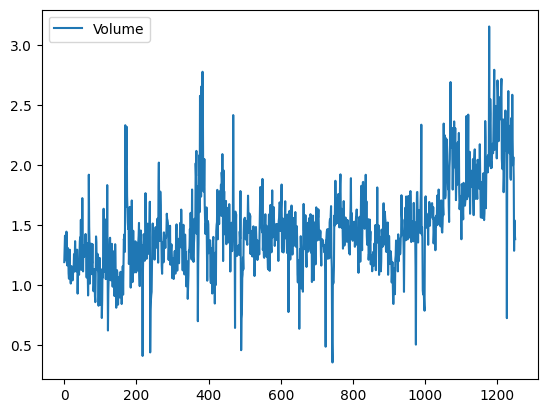

In [7]:
Smarket.plot(y='Volume');

**Logistic Regression**

In [8]:
allvars = Smarket.columns.drop(['Today','Direction','Year'])
design = MS(allvars)

X = design.fit_transform(Smarket)
y = Smarket.Direction == 1
glm = sm.GLM(y,
             X,
             family=sm.families.Binomial()) #tells statsmodels that the regression is logistic
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,-0.1260,0.241,-0.523,0.601
Lag1,-0.0731,0.050,-1.457,0.145
Lag2,-0.0423,0.050,-0.845,0.398
Lag3,0.0111,0.050,0.222,0.824
Lag4,0.0094,0.050,0.187,0.851
Lag5,0.0103,0.050,0.208,0.835
Volume,0.1354,0.158,0.855,0.392


In [9]:
results.params

intercept   -0.126000
Lag1        -0.073074
Lag2        -0.042301
Lag3         0.011085
Lag4         0.009359
Lag5         0.010313
Volume       0.135441
dtype: float64

In [10]:
results?

Type:            GLMResultsWrapper
String form:     <statsmodels.genmod.generalized_linear_model.GLMResultsWrapper object at 0x000002A9541BA870>
File:            c:\users\karti\appdata\local\programs\python\python312\lib\site-packages\statsmodels\genmod\generalized_linear_model.py
Docstring:      
Class to contain GLM results.

GLMResults inherits from statsmodels.LikelihoodModelResults

Attributes
----------
df_model : float
    See GLM.df_model
df_resid : float
    See GLM.df_resid
fit_history : dict
    Contains information about the iterations. Its keys are `iterations`,
    `deviance` and `params`.
model : class instance
    Pointer to GLM model instance that called fit.
nobs : float
    The number of observations n.
normalized_cov_params : ndarray
    See GLM docstring
params : ndarray
    The coefficients of the fitted model.  Note that interpretation
    of the coefficients often depends on the distribution family and the
    data.
pvalues : ndarray
    The two-tailed p-values 

In [11]:
results.pvalues

intercept    0.600700
Lag1         0.145232
Lag2         0.398352
Lag3         0.824334
Lag4         0.851445
Lag5         0.834998
Volume       0.392404
dtype: float64

In [12]:
probs = results.predict()
probs[:10]

array([0.50708413, 0.48146788, 0.48113883, 0.51522236, 0.51078116,
       0.50695646, 0.49265087, 0.50922916, 0.51761353, 0.48883778])

In [13]:
labels = np.array([0]*1250)
labels[probs>0.5] = 1

In [14]:
labels

array([1, 0, 0, ..., 1, 1, 1])

In [15]:
confusion_table(labels, Smarket.Direction)

Truth,0,1
Predicted,,
0,145,141
1,457,507


In [16]:
confusion_table?

Signature: confusion_table(predicted_labels, true_labels, labels=None)
Docstring:
Return a data frame version of confusion 
matrix with rows given by predicted label
and columns the truth.

Parameters
----------

predicted_labels: array-like
    These will form rows of confusion matrix.

true_labels: array-like
    These will form columns of confusion matrix.
File:      c:\users\karti\appdata\local\programs\python\python312\lib\site-packages\islp\__init__.py
Type:      function

In [17]:
c_table = confusion_table(labels, Smarket.Direction)
c_table

Truth,0,1
Predicted,,
0,145,141
1,457,507


In [18]:
(c_table[0][0] + c_table[1][1])/c_table.to_numpy().sum() , np.mean(labels == Smarket.Direction)

(0.5216, 0.5216)

In [19]:
train = (Smarket.Year < 2005)
Smarket_train = Smarket.loc[train]
Smarket_test = Smarket.loc[~train]
Smarket_test.shape

(252, 9)

In [20]:
train

0        True
1        True
2        True
3        True
4        True
        ...  
1245    False
1246    False
1247    False
1248    False
1249    False
Name: Year, Length: 1250, dtype: bool

In [21]:
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train,
                   X_train,
                   family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test) #As with linear regression, one can pass an optional exog argument consistent with a design matrix if desired

In [22]:
probs

998     0.528220
999     0.515669
1000    0.522652
1001    0.513854
1002    0.498334
          ...   
1245    0.483637
1246    0.506048
1247    0.516658
1248    0.516124
1249    0.508072
Length: 252, dtype: float64

In [23]:
D = Smarket.Direction
L_train, L_test = D.loc[train], D.loc[~train]

In [24]:
labels = np.zeros(252)
labels[probs>0.5] = 1
confusion_table(labels, L_test)

Truth,0,1
Predicted,,
0,77,97
1,34,44


In [25]:
np.mean(labels == L_test), np.mean(labels != L_test)

(0.4801587301587302, 0.5198412698412699)

In [26]:
model = MS(['Lag1','Lag2']).fit(Smarket)
X = model.transform(Smarket)
X_train, X_test = X.loc[train], X.loc[~train]
glm_train = sm.GLM(y_train,
                   X_train,
                   family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)
labels = np.zeros(252)
labels[probs>.5] = 1
confusion_table(labels, L_test)

Truth,0,1
Predicted,,
0,35,35
1,76,106


In [27]:
np.mean(labels == L_test), (106/(106+76))

(0.5595238095238095, 0.5824175824175825)

In [28]:
newdata = pd.DataFrame({'Lag1':[1.2,1.5],
                        'Lag2':[1.1,-.8]});
newX = model.transform(newdata)
probs = results.predict(newX)
probs

0    0.479146
1    0.496094
dtype: float64

In [29]:
labels = np.zeros(2)
labels[probs>.5] = 1
labels

array([0., 0.])

**Linear Discriminant Analysis (LDA)**

In [30]:
lda = LDA(store_covariance=True)

In [31]:
#ince the LDA estimator automatically adds an intercept, 
#we should remove the column corresponding to the intercept in both X_train and X_test. 

X_train, X_test = [M.drop(columns=['intercept'])
                   for M in [X_train, X_test]]
lda.fit(X_train, L_train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",True
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [32]:
'''
average of each predictor within each class [0 = "Down", 1 = "Up"], and are used by LDA as 
estimates of mu(k) these suggest there is a tendency for the previous 2 days' returns to be 
negative on days when the market increases, and a tendency for the previous days' returns to 
be positive on days when the market declines
'''

lda.means_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [33]:
lda.classes_

array([0, 1], dtype=int64)

In [34]:
'''
prior probabilities of each class
'''

lda.priors_

array([0.49198397, 0.50801603])

In [35]:
'''
linear combination of lag1 and lag2 for forming LDA decision rule, 
i.e. multipliers of the elements of X=x.
if -0.64xlag1 -0.51xlag2 is large, then LDA classifier will predict a market increase,
and if small, then the LDA classifier will predict a market decline.
'''

lda.scalings_

array([[-0.64201904],
       [-0.51352928]])

Q:
in LDA implementation I'm not following what scalings_ translates to in the derivations
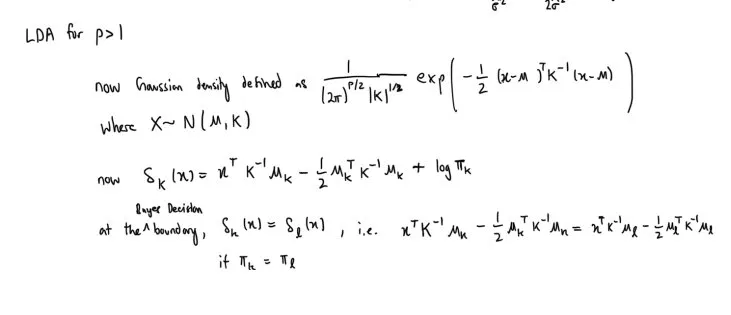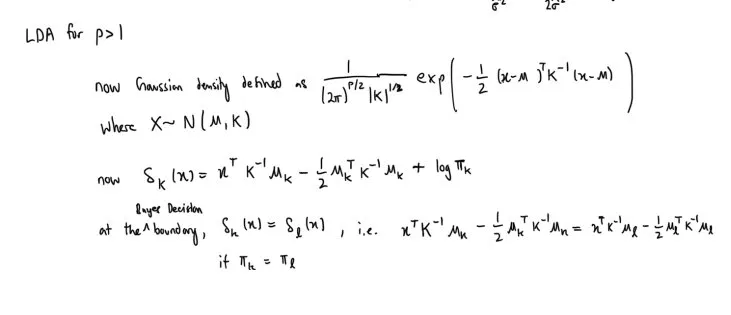

A:
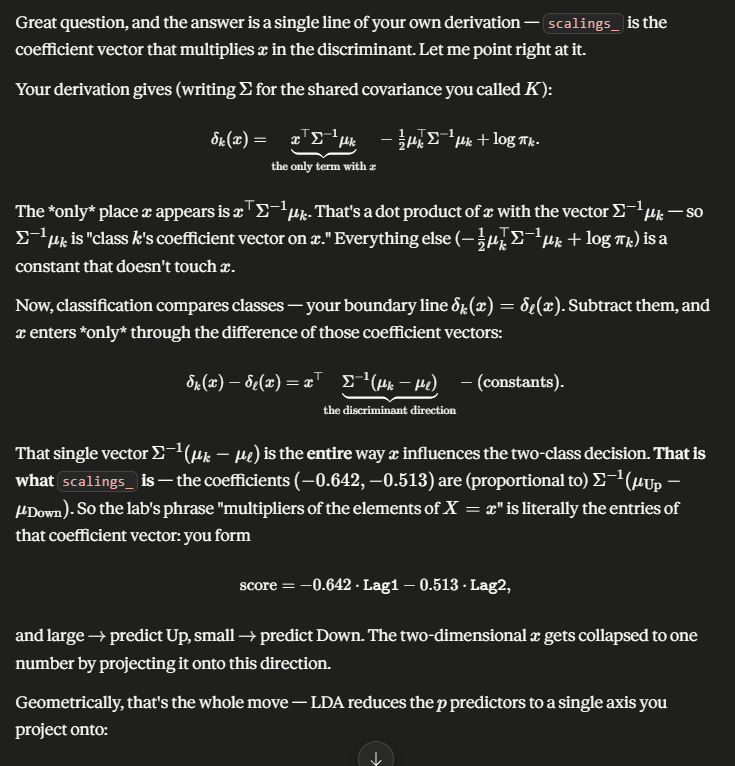
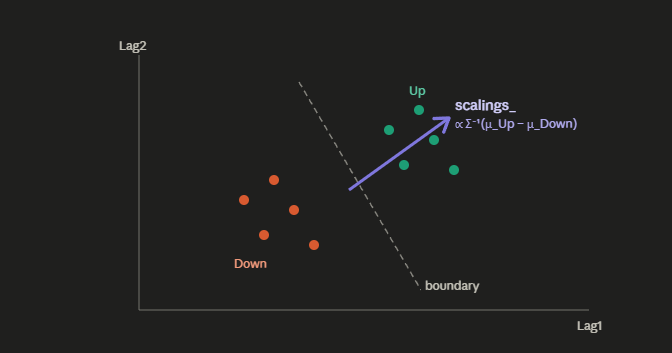
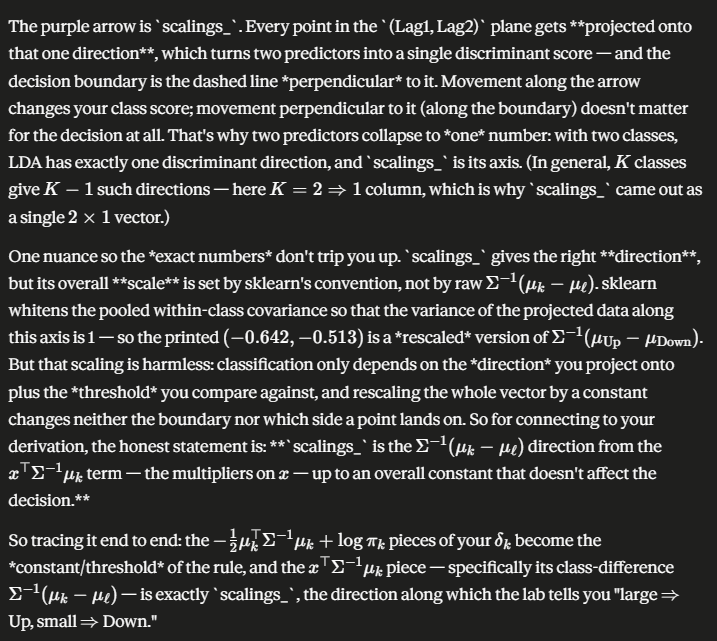

In [36]:
lda.covariance_

array([[ 1.50886781, -0.03340234],
       [-0.03340234,  1.5095363 ]])

Covariance matrix --
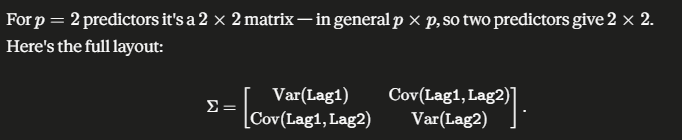
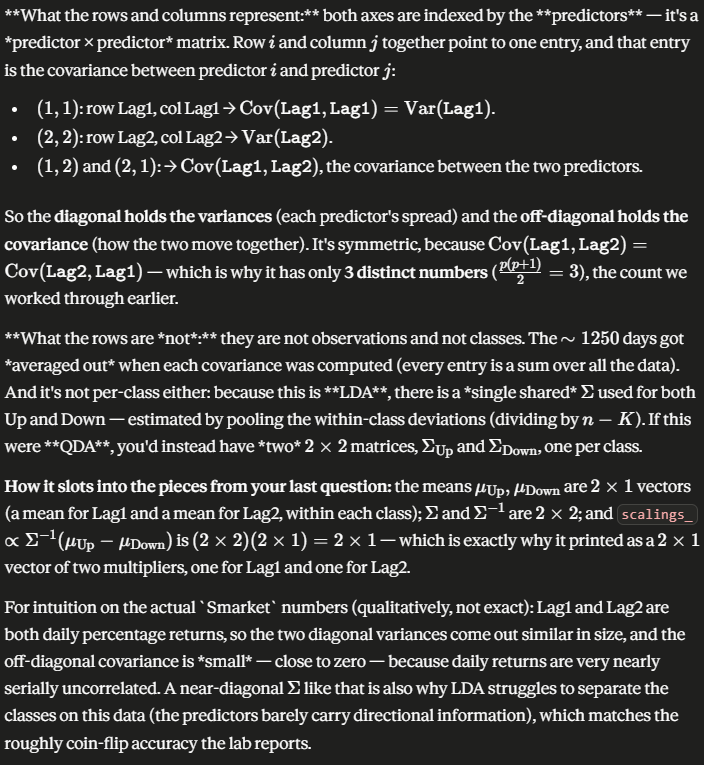

In [37]:
lda_pred = lda.predict(X_test)

In [38]:
confusion_table(lda_pred, L_test)

Truth,0,1
Predicted,,
0,35,35
1,76,106


In [39]:
lda_prob = lda.predict_proba(X_test)
lda_prob[0:5]

array([[0.49017925, 0.50982075],
       [0.4792185 , 0.5207815 ],
       [0.46681848, 0.53318152],
       [0.47400107, 0.52599893],
       [0.49278766, 0.50721234]])

In [40]:
np.all(
    np.where(lda_prob[:, 0] >= 0.5, 0, 1) == lda_pred
    )

True

In [41]:
np.sum(lda_prob[:,0] > 0.7)

0

**Quadratic Discriminant Analysis (QDA)**

In [42]:
qda = QDA(store_covariance=True)
qda.fit(X_train, L_train)

,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",True
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


In [43]:
qda.means_, qda.priors_

(array([[ 0.04279022,  0.03389409],
        [-0.03954635, -0.03132544]]),
 array([0.49198397, 0.50801603]))

In [44]:
'''
covariance of the first class, now each class will have it's own covariance matrix
'''
qda.covariance_[0]

array([[ 1.50662277, -0.03924806],
       [-0.03924806,  1.53559498]])

In [45]:
qda_pred = qda.predict(X_test)
qda_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

In [46]:
confusion_table(qda_pred, L_test)

Truth,0,1
Predicted,,
0,30,20
1,81,121


In [47]:
np.mean(qda_pred == L_test)

0.5992063492063492

**Naive Bayes**

In [48]:
NB = GaussianNB()
NB.fit(X_train, L_train) #kernel density method can also be used to estimate the distributions (make discrete continuous)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [49]:
NB.classes_

array([0, 1], dtype=int64)

In [50]:
NB.class_prior_

array([0.49198397, 0.50801603])

In [51]:
'''
# rows = # classes, # cols = # features
'''

NB.theta_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [52]:
NB.var_

array([[1.50355429, 1.53246749],
       [1.51401364, 1.48732877]])

In [53]:
NB?

Type:        GaussianNB
String form: GaussianNB()
File:        c:\users\karti\appdata\local\programs\python\python312\lib\site-packages\sklearn\naive_bayes.py
Docstring:  
Gaussian Naive Bayes (GaussianNB).

Can perform online updates to model parameters via :meth:`partial_fit`.
For details on algorithm used to update feature means and variance online,
see `Stanford CS tech report STAN-CS-79-773 by Chan, Golub, and LeVeque
<http://i.stanford.edu/pub/cstr/reports/cs/tr/79/773/CS-TR-79-773.pdf>`_.

Read more in the :ref:`User Guide <gaussian_naive_bayes>`.

Parameters
----------
priors : array-like of shape (n_classes,), default=None
    Prior probabilities of the classes. If specified, the priors are not
    adjusted according to the data.

var_smoothing : float, default=1e-9
    Portion of the largest variance of all features that is added to
    variances for calculation stability.

    .. versionadded:: 0.20

Attributes
----------
class_count_ : ndarray of shape (n_classes,)
    numb

In [54]:
X_train[L_train == 0].mean()

Lag1    0.042790
Lag2    0.033894
dtype: float64

In [55]:
X_train[L_train == 0].var(ddof=0)

Lag1    1.503554
Lag2    1.532467
dtype: float64

In [56]:
nb_labels = NB.predict(X_test)
confusion_table(nb_labels, L_test)

Truth,0,1
Predicted,,
0,29,20
1,82,121


In [57]:
NB.predict_proba(X_test)[:5]

array([[0.4873288 , 0.5126712 ],
       [0.47623584, 0.52376416],
       [0.46529531, 0.53470469],
       [0.47484469, 0.52515531],
       [0.49020587, 0.50979413]])

**K-Nearest Neighbors**

In [58]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, L_train)
knn1_pred = knn1.predict(X_test)
confusion_table(knn1_pred, L_test)

Truth,0,1
Predicted,,
0,43,58
1,68,83


In [59]:
(83+43)/252, np.mean(knn1_pred == L_test)

(0.5, 0.5)

In [60]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3_pred = knn3.fit(X_train,L_train).predict(X_test)
np.mean(knn3_pred == L_test)

0.5317460317460317

In [61]:
Caravan = load_data('Caravan')
Purchase = Caravan.Purchase
Purchase.value_counts()

Purchase
No     5474
Yes     348
Name: count, dtype: int64

In [62]:
348/5822

0.05977327378907592

In [63]:
feature_df = Caravan.drop(columns=["Purchase"])
feature_df

,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,ALEVEN,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND
0,33,1,3,2,8,0,5,1,3,7,...,0,0,0,0,1,0,0,0,0,0
1,37,1,2,2,8,1,4,1,4,6,...,0,0,0,0,1,0,0,0,0,0
2,37,1,2,2,8,0,4,2,4,3,...,0,0,0,0,1,0,0,0,0,0
3,9,1,3,3,3,2,3,2,4,5,...,0,0,0,0,1,0,0,0,0,0
4,40,1,4,2,10,1,4,1,4,7,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5817,36,1,1,2,8,0,6,1,2,1,...,2,0,0,0,1,0,0,0,0,0
5818,35,1,4,4,8,1,4,1,4,6,...,0,0,0,0,1,0,0,0,0,0
5819,33,1,3,4,8,0,6,0,3,5,...,0,0,0,0,1,0,0,0,0,0
5820,34,1,3,2,8,0,7,0,2,7,...,0,0,0,0,0,0,0,0,0,0


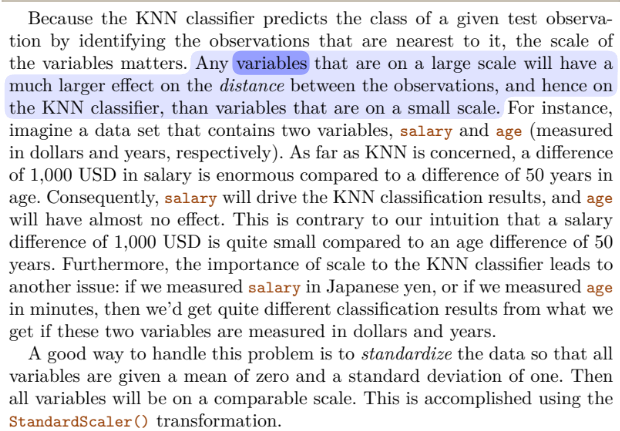

In [64]:
scaler = StandardScaler(with_mean=True, #indicates whether/not we should subtract the mean
                        with_std=True, #indicates whether/not we should scale cols to have stdev 1
                        copy=True) #indicates we'll copy data, rather than do calculations in place where possible

In [65]:
scaler.fit(feature_df)
X_standardized = scaler.transform(feature_df)

feature_standardized = pd.DataFrame(
                            X_standardized,
                            columns=feature_df.columns);
feature_standardized.std()

MOSTYPE     1.000086
MAANTHUI    1.000086
MGEMOMV     1.000086
MGEMLEEF    1.000086
MOSHOOFD    1.000086
              ...   
AZEILPL     1.000086
APLEZIER    1.000086
AFIETS      1.000086
AINBOED     1.000086
ABYSTAND    1.000086
Length: 85, dtype: float64

In [66]:
feature_standardized.std(ddof=0)

MOSTYPE     1.0
MAANTHUI    1.0
MGEMOMV     1.0
MGEMLEEF    1.0
MOSHOOFD    1.0
           ... 
AZEILPL     1.0
APLEZIER    1.0
AFIETS      1.0
AINBOED     1.0
ABYSTAND    1.0
Length: 85, dtype: float64

In [67]:
scaler.fit(feature_df)
X_standardized = scaler.transform(feature_df)

# Apply the Bessel's correction factor adjustment
n = feature_df.shape[0]
correction_factor = np.sqrt((n - 1)/n)
X_standardized_corrected = X_standardized * correction_factor

# Wrap into the DataFrame
feature_standardized = pd.DataFrame(
    X_standardized_corrected,
    columns=feature_df.columns
)

# This will now output exactly 1.000000
feature_standardized.std()

MOSTYPE     1.0
MAANTHUI    1.0
MGEMOMV     1.0
MGEMLEEF    1.0
MOSHOOFD    1.0
           ... 
AZEILPL     1.0
APLEZIER    1.0
AFIETS      1.0
AINBOED     1.0
ABYSTAND    1.0
Length: 85, dtype: float64

In [68]:
# Mean-center and divide by sample standard deviation 1/(n-1)
feature_standardized = (feature_df - feature_df.mean()) / feature_df.std()

# This will now output exactly 1.000000
feature_standardized.std()

MOSTYPE     1.0
MAANTHUI    1.0
MGEMOMV     1.0
MGEMLEEF    1.0
MOSHOOFD    1.0
           ... 
AZEILPL     1.0
APLEZIER    1.0
AFIETS      1.0
AINBOED     1.0
ABYSTAND    1.0
Length: 85, dtype: float64

In [69]:
(X_train,
 X_test,
 y_train,
 y_test) = train_test_split(feature_standardized,
                            Purchase,
                            test_size=1000,
                            random_state=0)

In [70]:
?train_test_split

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of indexables with same length / shape[0]
    Allowed inputs are lists, numpy arrays, scipy-sparse
    matrices or pandas dataframes.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement of the train size. If ``train_size`` is also None, it will
    be set to 0.25.

trai

In [71]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1_pred = knn1.fit(X_train, y_train).predict(X_test)
np.mean(y_test != knn1_pred), np.mean(y_test != "No")

(0.111, 0.067)

In [72]:
confusion_table(knn1_pred, y_test)

Truth,No,Yes
Predicted,,
No,880,58
Yes,53,9


In [73]:
9/(53+9) #precision, compare to base 6.7%)

0.14516129032258066

In [74]:
9/(58+9) #recall

0.13432835820895522

In [75]:
for K in range(1,6):
    knn = KNeighborsClassifier(n_neighbors=K)
    knn_pred = knn.fit(X_train, y_train).predict(X_test)
    C = confusion_table(knn_pred, y_test)
    templ = ('K={0:d}: # predicted to rent: {1:>2},' +
             ' # who did rent {2:d}, accuracy {3:.1%}')
    pred = C.loc['Yes'].sum()
    did_rent = C.loc['Yes','Yes']
    print(templ.format(
            K,
            pred,
            did_rent,
            did_rent/pred))

K=1: # predicted to rent: 62, # who did rent 9, accuracy 14.5%
K=2: # predicted to rent:  6, # who did rent 1, accuracy 16.7%
K=3: # predicted to rent: 20, # who did rent 3, accuracy 15.0%
K=4: # predicted to rent:  4, # who did rent 0, accuracy 0.0%
K=5: # predicted to rent:  7, # who did rent 1, accuracy 14.3%


In [76]:
logit = LogisticRegression(C=1e10, solver='liblinear') #default C=1, solver='liblinear' above to avoid a warning with the default solver which would indicate that the algorithm does not converge
logit.fit(X_train, y_train)
logit_pred = logit.predict_proba(X_test)
logit_labels = np.where(logit_pred[:,1] > .5, 'Yes', 'No')
confusion_table(logit_labels, y_test)

Truth,No,Yes
Predicted,,
No,931,67
Yes,2,0


In [77]:
(y_test == 'Yes').sum()/y_test.size

0.067

In [78]:
logit_labels = np.where(logit_pred[:,1]>0.25, 'Yes', 'No')
confusion_table(logit_labels, y_test)

Truth,No,Yes
Predicted,,
No,913,58
Yes,20,9


In [79]:
9/(20+9) 

0.3103448275862069

**Linear and Poisson Regression on Bikeshare Data**

In [80]:
Bike = load_data('Bikeshare')

In [81]:
Bike.shape, Bike.columns

((8645, 15),
 Index(['season', 'mnth', 'day', 'hr', 'holiday', 'weekday', 'workingday',
        'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
        'registered', 'bikers'],
       dtype='object'))

In [82]:
X = MS(['mnth',
        'hr',
        'workingday',
        'temp',
        'weathersit']).fit_transform(Bike)
Y = Bike['bikers']
M_lm = sm.OLS(Y, X).fit()
summarize(M_lm)

,coef,std err,t,P>|t|
intercept,-68.6317,5.307,-12.932,0.000
mnth[Feb],6.8452,4.287,1.597,0.110
mnth[March],16.5514,4.301,3.848,0.000
mnth[April],41.4249,4.972,8.331,0.000
mnth[May],72.5571,5.641,12.862,0.000
mnth[June],67.8187,6.544,10.364,0.000
mnth[July],45.3245,7.081,6.401,0.000
mnth[Aug],53.2430,6.640,8.019,0.000
mnth[Sept],66.6783,5.925,11.254,0.000
mnth[Oct],75.8343,4.950,15.319,0.000


In [83]:
hr_encode = contrast('hr', 'sum')
mnth_encode = contrast('mnth', 'sum')

In [84]:
X2 = MS([mnth_encode,
         hr_encode,
         'workingday',
         'temp',
         'weathersit']).fit_transform(Bike)
M2_lm = sm.OLS(Y, X2).fit()
S2 = summarize(M2_lm)
S2

,coef,std err,t,P>|t|
intercept,73.5974,5.132,14.340,0.000
mnth[Jan],-46.0871,4.085,-11.281,0.000
mnth[Feb],-39.2419,3.539,-11.088,0.000
mnth[March],-29.5357,3.155,-9.361,0.000
mnth[April],-4.6622,2.741,-1.701,0.089
mnth[May],26.4700,2.851,9.285,0.000
mnth[June],21.7317,3.465,6.272,0.000
mnth[July],-0.7626,3.908,-0.195,0.845
mnth[Aug],7.1560,3.535,2.024,0.043
mnth[Sept],20.5912,3.046,6.761,0.000


In [85]:
np.sum((M_lm.fittedvalues - M2_lm.fittedvalues)**2)

8.4285149811757e-19

In [86]:
np.allclose(M_lm.fittedvalues, M2_lm.fittedvalues)

True

In [87]:
coef_month = S2[S2.index.str.contains('mnth')]['coef']
coef_month

mnth[Jan]     -46.0871
mnth[Feb]     -39.2419
mnth[March]   -29.5357
mnth[April]    -4.6622
mnth[May]      26.4700
mnth[June]     21.7317
mnth[July]     -0.7626
mnth[Aug]       7.1560
mnth[Sept]     20.5912
mnth[Oct]      29.7472
mnth[Nov]      14.2229
Name: coef, dtype: float64

In [88]:
months = Bike['mnth'].dtype.categories
coef_month = pd.concat([
                coef_month,
                pd.Series([-coef_month.sum()],
                          index=['mnth[Dec]'
                                ])
                ])
coef_month

mnth[Jan]     -46.0871
mnth[Feb]     -39.2419
mnth[March]   -29.5357
mnth[April]    -4.6622
mnth[May]      26.4700
mnth[June]     21.7317
mnth[July]     -0.7626
mnth[Aug]       7.1560
mnth[Sept]     20.5912
mnth[Oct]      29.7472
mnth[Nov]      14.2229
mnth[Dec]       0.3705
dtype: float64

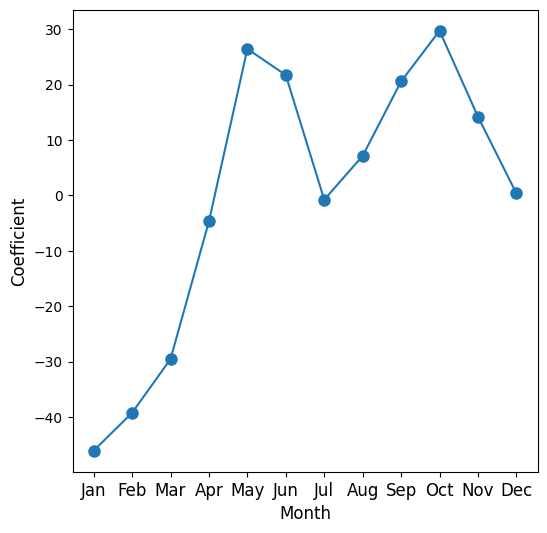

In [89]:
fig_month, ax_month = subplots(figsize=(6,6))
x_month = np.arange(coef_month.shape[0])
ax_month.plot(x_month, coef_month, marker='o', ms=8)
ax_month.set_xticks(x_month)
ax_month.set_xticklabels([l[5:8] for l in coef_month.index], fontsize = 12)
ax_month.set_xlabel('Month', fontsize=12)
ax_month.set_ylabel('Coefficient', fontsize=12);

In [90]:
coef_hr = S2[S2.index.str.contains('hr')]['coef']
coef_hr = coef_hr.reindex(['hr[{0}]'.format(h) for h in range(23)])
coef_hr = pd.concat([coef_hr, pd.Series([-coef_hr.sum()],
                                        index=['hr[23]'])])

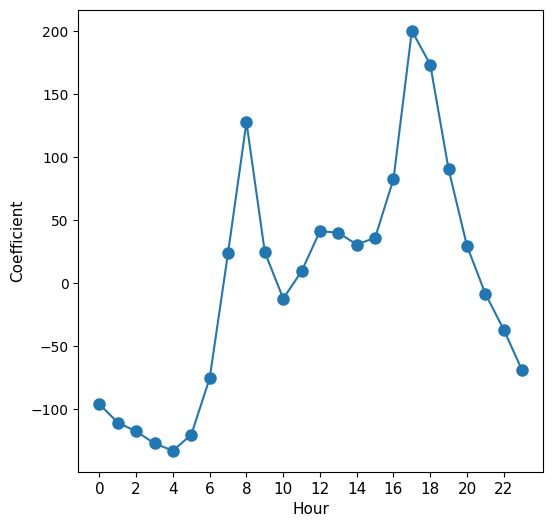

In [91]:
fig_hr, ax_hr = subplots(figsize=(6,6))
x_hr = np.arange(coef_hr.shape[0])
ax_hr.plot(x_hr, coef_hr, marker='o', ms=8)
ax_hr.set_xticks(x_hr[::2])
ax_hr.set_xticklabels(range(24)[::2], fontsize=11)
ax_hr.set_xlabel('Hour', fontsize=11)
ax_hr.set_ylabel('Coefficient', fontsize=11); 

**Poisson Regression**

In [92]:
M_pois = sm.GLM(Y, X2, family=sm.families.Poisson()).fit()

In [93]:
S_pois = summarize(M_pois)
coef_month = S_pois[S_pois.index.str.contains('mnth')]['coef']
coef_month = pd.concat([coef_month, pd.Series([-coef_month.sum()],
                                              index=['mnth[Dec]'])])
coef_hr = S_pois[S_pois.index.str.contains('hr')]['coef']
coef_hr = pd.concat([coef_hr,
                     pd.Series([-coef_hr.sum()],
                     index=['hr[23]'])])

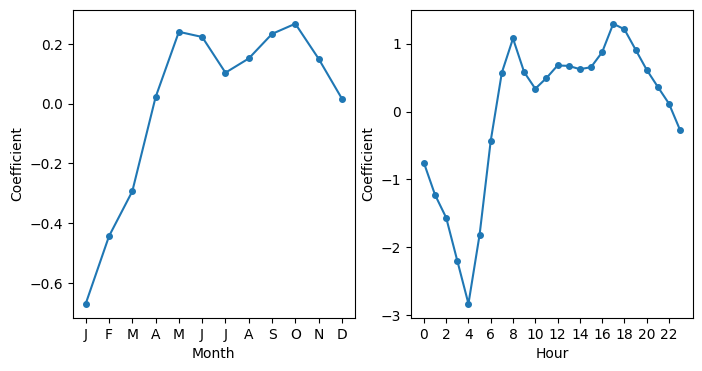

In [94]:
fig_pois, (ax_month, ax_hr) = subplots(1,2, figsize = (8,4))
ax_month.plot(x_month, coef_month, marker='o', ms=4)
ax_month.set_xticks(x_month)
ax_month.set_xticklabels([l[5] for l in coef_month.index], fontsize=10)
ax_month.set_xlabel('Month', fontsize=10) 
ax_month.set_ylabel('Coefficient', fontsize=10) 
ax_hr.plot(x_hr, coef_hr, marker='o', ms=4) 
ax_hr.set_xticks(range(24)[::2], labels=range(24)[::2], fontsize=10) 
ax_hr.set_xlabel('Hour', fontsize=10) 
ax_hr.set_ylabel('Coefficient', fontsize=10); 

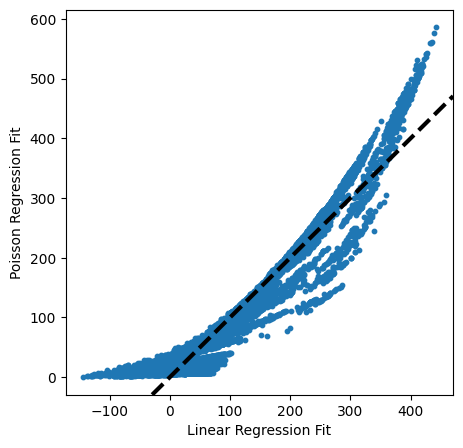

In [95]:
fig, ax = subplots(figsize=(5,5))
ax.scatter(M2_lm.fittedvalues,
           M_pois.fittedvalues,
           s=10)
ax.set_xlabel('Linear Regression Fit', fontsize=10)
ax.set_ylabel('Poisson Regression Fit', fontsize=10)
ax.axline([0,0], c='black', linewidth=3, linestyle='--', slope=1);